In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import GroupKFold, cross_validate, learning_curve, RandomizedSearchCV, GroupShuffleSplit, cross_val_score
from sklearn.compose import TransformedTargetRegressor

import optuna

from scipy.optimize import curve_fit
from scipy.stats import t

In [129]:
file_path = "samples/dataset.xlsx"

df = pd.read_excel(file_path)

df.columns = df.columns.str.strip()
df = df.dropna(how="all").reset_index(drop=True)

df["AspectRatio"] = df["MaxHeight"] / (df["Area"] ** 0.5 + 1e-6)
df["Density"] = df["Volume"] / (df["Area"] + 1e-6)
df["NormDeviation"] = np.sqrt(df["CenterDiviation"] / (df["Area"] ** 0.5 + 1e-6))

numeric_cols = [
    "Volume",
    "Area",
    "MaxHeight",
    "CenterDiviation",
    "UsedCoilArea",
    "SensorTemp",
    "SensorValueRAW",
    "KT10valueMax",
    "KT10valueCenterDiviation",
    "AspectRatio",
    "Density",
    "NormDeviation"
]

numeric_cols = [c for c in numeric_cols if c in df.columns]

if numeric_cols:
    df[numeric_cols] = df[numeric_cols].astype(str).map(
        lambda x: x.replace(",", ".") if isinstance(x, str) else x
    )
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

if "SensorId" in df.columns:
    df["SensorId"] = pd.to_numeric(df["SensorId"], errors="coerce").astype("Int64")

if "DateTime" in df.columns:
    df["DateTime"] = pd.to_datetime(df["DateTime"], format="%Y-%m-%d_%H-%M-%S", errors="coerce")

print(df.head())
print(df.info())

      Label            DateTime  SensorId   Volume     Area  MaxHeight  \
0  UL17.1.0 2026-03-12 13:56:15         5  12.9742  16.0051    1.23164   
1  UL17.1.0 2026-03-12 13:56:15         5  12.9742  16.0051    1.23164   
2  UL17.1.0 2026-03-12 13:56:15         5  12.9742  16.0051    1.23164   
3    G1.1.0 2026-03-13 09:33:58         6  32.2500  14.5093    3.23182   
4    G1.1.0 2026-03-13 09:33:58         6  32.2500  14.5093    3.23182   

   CenterDiviation  UsedCoilArea  SensorTemp  SensorValueRAW  KT10valueMax  \
0         13.85000      0.569170        22.0         224.584           6.5   
1          2.77000      0.770751        22.0         286.584           6.5   
2          8.31000      0.687747        22.0         227.584           6.5   
3         14.86550      0.537549        19.0         295.870          15.6   
4          6.06901      0.644269        19.0         492.870          15.6   

   AspectRatio   Density  NormDeviation  
0     0.307861  0.810629       1.860631  
1 

In [130]:
df.describe()

,DateTime,SensorId,Volume,Area,MaxHeight,CenterDiviation,UsedCoilArea,SensorTemp,SensorValueRAW,KT10valueMax,AspectRatio,Density,NormDeviation
count,699,699.0,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,2026-03-21 19:00:41.834048256,5.519313,25.868623,15.417444,2.356228,10.082834,0.577126,20.250646,1003.601320,37.767828,0.628509,1.549762,1.599875
min,2026-03-12 13:56:15,4.0,5.138910,5.384880,0.901440,2.770000,0.181818,18.000000,1.385050,0.030000,0.243291,0.659162,0.753063
25%,2026-03-13 12:42:18,5.0,12.160200,9.872280,1.847840,6.162920,0.432806,20.000000,78.324100,1.900000,0.507962,1.188760,1.276696
50%,2026-03-25 11:07:39,5.0,20.480900,13.761400,2.294260,8.310000,0.565217,20.500000,500.551000,17.400000,0.631573,1.480240,1.526607
75%,2026-03-25 13:46:45,6.0,27.811700,17.276500,2.703760,14.865500,0.703557,20.500000,1155.590000,42.200000,0.730181,1.883699,1.931054
max,2026-03-25 15:00:51,11.0,98.867000,36.946300,4.050300,25.168100,1.000000,22.433300,19953.900000,624.000000,1.188998,2.924889,2.873673
std,NaN,0.67972,20.661675,7.831001,0.714266,4.956450,0.182384,0.756576,2366.694576,85.222082,0.170719,0.491802,0.426146


In [131]:
corr_matrix = df[numeric_cols].corr()
corr_matrix["KT10valueMax"].sort_values(ascending=False)

KT10valueMax       1.000000
SensorValueRAW     0.985214
Volume             0.358031
Density            0.323885
Area               0.313391
UsedCoilArea       0.286110
MaxHeight          0.168793
CenterDiviation    0.053754
SensorTemp        -0.025260
NormDeviation     -0.088316
AspectRatio       -0.092701
Name: KT10valueMax, dtype: float64

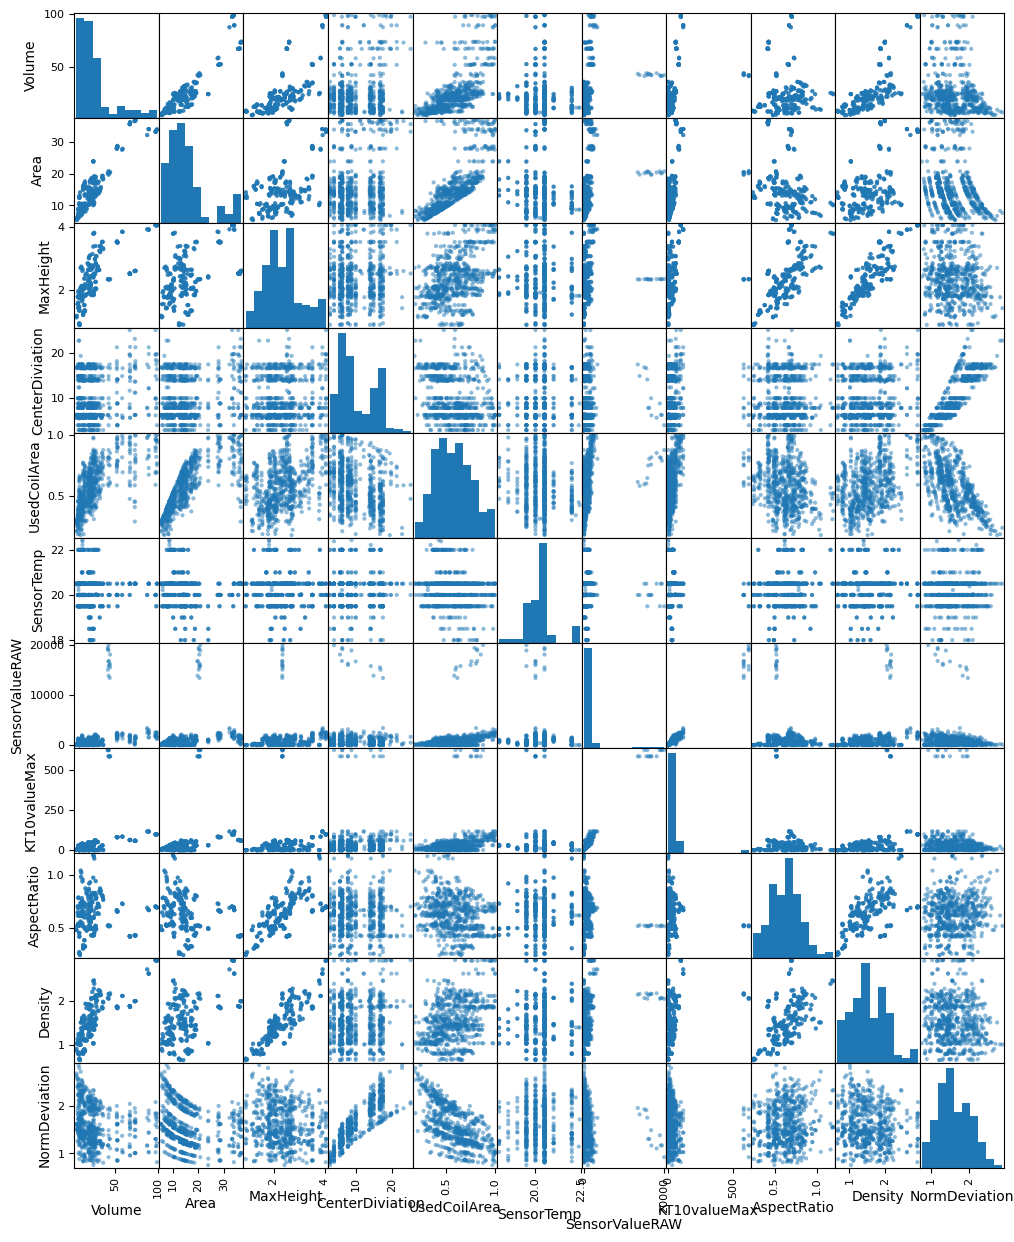

In [132]:
from pandas.plotting import scatter_matrix

scatter_matrix(df[numeric_cols], figsize=(12, 15))
plt.show()

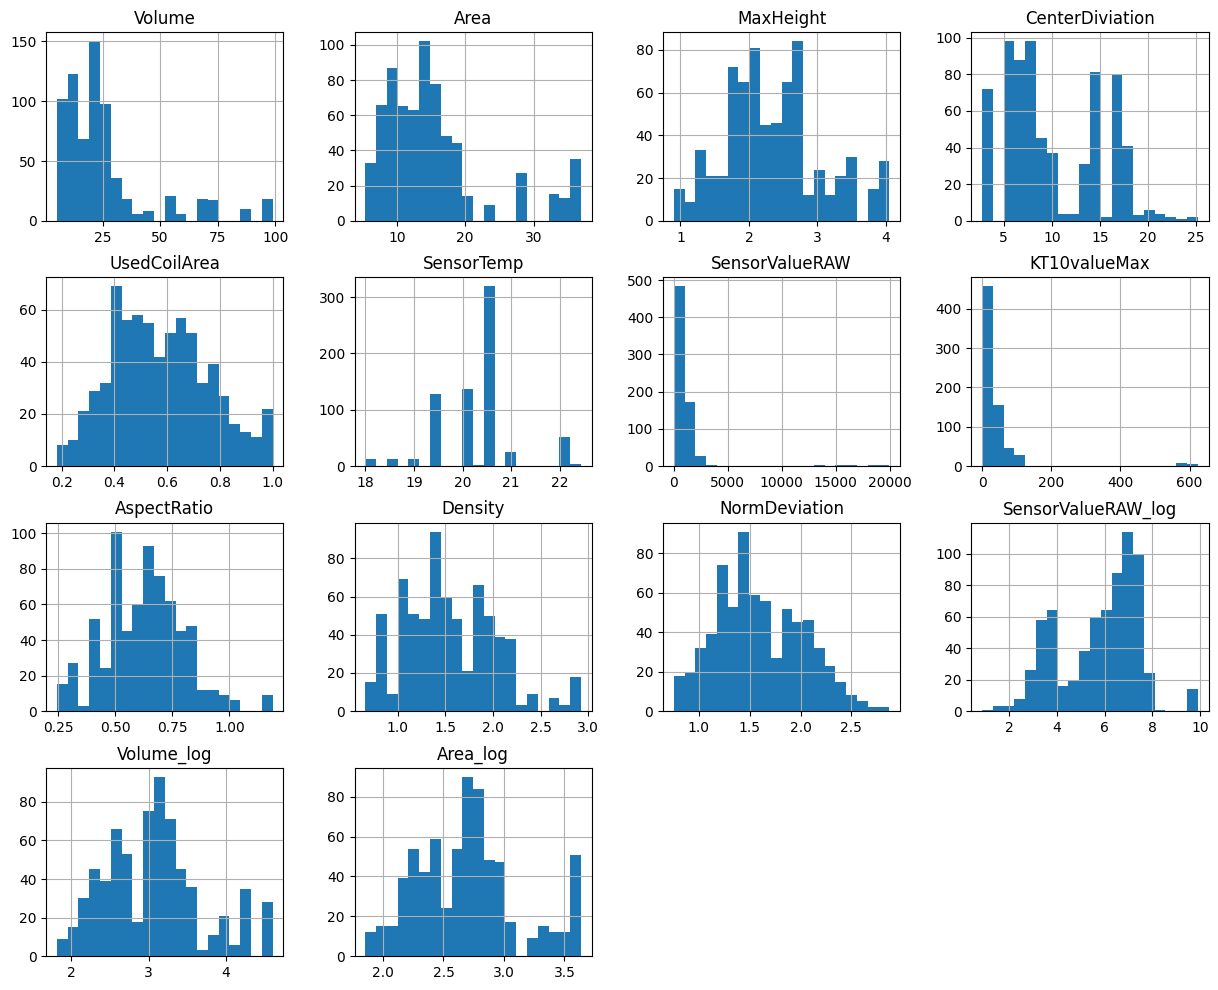

In [133]:
df_enhanced = df[numeric_cols].copy()

for col in ["SensorValueRAW", "Volume", "Area"]:
    if col in df_enhanced.columns:
        df_enhanced[f"{col}_log"] = np.log1p(df_enhanced[col].clip(lower=0))

df_enhanced.hist(bins=20, figsize=(15, 12), grid=True)
plt.show()

In [134]:
from sklearn.base import BaseEstimator, TransformerMixin

class LogFeaturesTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        self.columns_ = [col for col in self.columns if col in X.columns]
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columns_:
            X[col] = np.log1p(X[col].clip(lower=0))
        return X

R^2 per fold: [0.96373976 0.84051909 0.9851987  0.99151316 0.95032889 0.94761173
 0.90355025 0.85794598 0.90459114 0.97301129]
RMSE per fold: [ 5.62858791  9.42573979  4.80569524 16.1401614   3.83474468  4.55874735
  5.1370663   4.97571067 12.76473327 27.72185536]

Overall Performance:
R^2  : 0.9318 ± 0.0501
RMSE: 9.4993 ± 7.2099


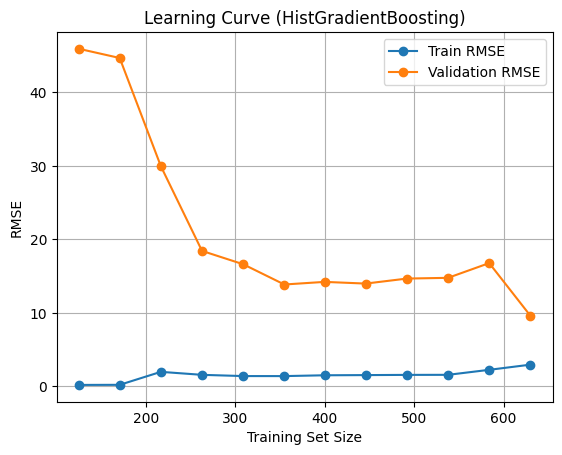

In [140]:
{'max_iter': 494, 'max_depth': 5, 'min_samples_leaf': 13, 'learning_rate': 0.14115471245558034, 'l2_regularization': 0.21303391226928223, 'max_leaf_nodes': 91}

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", TransformedTargetRegressor(
        regressor=HistGradientBoostingRegressor(
            random_state=42,
            max_iter=494,
            max_depth=5,
            min_samples_leaf=13,
            learning_rate= 0.14115471245558034,
            l2_regularization=0.21303391226928223,
            max_leaf_nodes=91,
        ),        
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

target_col = "KT10valueMax"

feature_cols = [
    "SensorId",
    "Volume",
    "Area",
    "MaxHeight",
    "CenterDiviation",
    "UsedCoilArea",
    "SensorTemp",
    "SensorValueRAW",
]

feature_cols = [col for col in feature_cols if col in df.columns]

model_df = df[["Label", target_col] + feature_cols].dropna(subset=[target_col]).copy()

X = model_df[feature_cols]
y = model_df[target_col]
groups = model_df["Label"]

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error"
}

kf = GroupKFold(n_splits=10)
results = cross_validate(
    pipeline,
    X,
    y,
    cv=kf,
    groups=groups,
    scoring=scoring,
    n_jobs=-1
)

r2_scores = results["test_r2"]
rmse_scores = -results["test_rmse"]

print(f"R^2 per fold: {r2_scores}")
print(f"RMSE per fold: {rmse_scores}")

print("\nOverall Performance:")
print(f"R^2  : {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")
print(f"RMSE: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")

train_sizes = np.linspace(0.2, 1.0, 12)

train_sizes_abs, train_scores, val_scores = learning_curve(
    estimator=pipeline,
    X=X,
    y=y,
    groups=groups,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    train_sizes=train_sizes,
    n_jobs=-1,
    random_state=42
)

train_rmse = -train_scores
val_rmse = -val_scores

train_mean = train_rmse.mean(axis=1)
val_mean = val_rmse.mean(axis=1)

plt.figure()
plt.plot(train_sizes_abs, train_mean, marker="o", label="Train RMSE")
plt.plot(train_sizes_abs, val_mean, marker="o", label="Validation RMSE")

plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.title("Learning Curve (HistGradientBoosting)")
plt.legend()
plt.grid(True)
plt.show()

In [136]:
def objective(trial):
    params = {
        "model__regressor__max_iter":         trial.suggest_int("max_iter", 100, 500),
        "model__regressor__max_depth":        trial.suggest_int("max_depth", 3, 10),
        "model__regressor__min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 50),
        "model__regressor__learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "model__regressor__l2_regularization":trial.suggest_float("l2_regularization", 0.0, 1.0),
        "model__regressor__max_leaf_nodes":   trial.suggest_int("max_leaf_nodes", 20, 100),
    }
    pipeline.set_params(**params)
    cv_results = cross_validate(
        pipeline, X, y,
        cv=kf, groups=groups,
        scoring={"rmse": "neg_root_mean_squared_error", "r2": "r2"},
        n_jobs=-1
    )
    trial.set_user_attr("std_rmse",  cv_results["test_rmse"].std())
    trial.set_user_attr("mean_r2",   cv_results["test_r2"].mean())
    trial.set_user_attr("params",    params)
    return -cv_results["test_rmse"].mean()

optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100, show_progress_bar=True)

# Build results dataframe matching RandomizedSearchCV output
results = pd.DataFrame([{
    "params":    {k.replace("model__regressor__", ""): v for k, v in t.user_attrs["params"].items()},
    "mean_rmse": t.value,
    "std_rmse":  t.user_attrs["std_rmse"],
    "mean_r2":   t.user_attrs["mean_r2"],
} for t in study.trials])

n_splits = kf.get_n_splits()
results["se_rmse"] = results["std_rmse"] / np.sqrt(n_splits)

# 1-SE rule
best_idx   = results["mean_rmse"].idxmin()
best_mean  = results.loc[best_idx, "mean_rmse"]
best_se    = results.loc[best_idx, "se_rmse"]
threshold  = best_mean + best_se

candidates = results[results["mean_rmse"] <= threshold].copy()
candidates["rank_std"]       = candidates["std_rmse"].rank(method="min")
candidates["rank_r2"]        = (-candidates["mean_r2"]).rank(method="min")
candidates["rank_mean_rmse"] = candidates["mean_rmse"].rank(method="min")
candidates["rank_sum"]       = (
    candidates["rank_mean_rmse"] +
    candidates["rank_std"] +
    candidates["rank_r2"]
)

best_row = candidates.sort_values(
    ["rank_sum", "std_rmse", "mean_r2"],
    ascending=[True, True, False]
).iloc[0]

print("Best Parameters:")
print(best_row["params"])
print("\nBest Metrics:")
print(f"Mean RMSE: {best_row['mean_rmse']:.4f}")
print(f"Std RMSE : {best_row['std_rmse']:.4f}")
print(f"SE RMSE  : {best_row['se_rmse']:.4f}")
print(f"Mean R^2 : {best_row['mean_r2']:.4f}")
print(f"1-SE threshold: {threshold:.4f}")

display_cols = [
    "params", "mean_rmse", "std_rmse", "se_rmse", "mean_r2",
    "rank_mean_rmse", "rank_std", "rank_r2", "rank_sum",
]
top_results = candidates[display_cols].sort_values(["rank_sum", "std_rmse"]).head(10)
top_results

  0%|          | 0/100 [00:00<?, ?it/s]

Best Parameters:
{'max_iter': 494, 'max_depth': 5, 'min_samples_leaf': 13, 'learning_rate': 0.14115471245558034, 'l2_regularization': 0.21303391226928223, 'max_leaf_nodes': 91}

Best Metrics:
Mean RMSE: 9.4993
Std RMSE : 7.2099
SE RMSE  : 2.2800
Mean R^2 : 0.9318
1-SE threshold: 11.4442


,params,mean_rmse,std_rmse,se_rmse,mean_r2,rank_mean_rmse,rank_std,rank_r2,rank_sum
13,"{'max_iter': 494, 'max_depth': 5, 'min_samples...",9.499304,7.209935,2.279981,0.931801,4.0,3.0,10.0,17.0
95,"{'max_iter': 325, 'max_depth': 5, 'min_samples...",9.577194,7.597729,2.402613,0.933979,8.0,5.0,4.0,17.0
35,"{'max_iter': 463, 'max_depth': 7, 'min_samples...",9.259900,6.907344,2.184294,0.930686,1.0,1.0,16.0,18.0
32,"{'max_iter': 490, 'max_depth': 7, 'min_samples...",9.456204,7.674410,2.426862,0.931562,2.0,6.0,12.0,20.0
96,"{'max_iter': 321, 'max_depth': 5, 'min_samples...",9.534262,7.971153,2.520700,0.937613,5.0,15.0,2.0,22.0
58,"{'max_iter': 470, 'max_depth': 7, 'min_samples...",9.466942,7.784337,2.461624,0.931180,3.0,9.0,14.0,26.0
97,"{'max_iter': 322, 'max_depth': 5, 'min_samples...",9.602783,7.052432,2.230175,0.928621,10.0,2.0,20.0,32.0
69,"{'max_iter': 389, 'max_depth': 8, 'min_samples...",9.710487,8.032188,2.540001,0.932869,15.0,16.0,8.0,39.0
52,"{'max_iter': 446, 'max_depth': 8, 'min_samples...",9.543629,7.754292,2.452122,0.926576,6.0,8.0,26.0,40.0
76,"{'max_iter': 472, 'max_depth': 7, 'min_samples...",9.588371,7.360378,2.327556,0.923763,9.0,4.0,31.0,44.0


Fitted parameters:
a = 10.79531  (95% CI: -13.57580, 35.16642)
b = 3.07326  (95% CI: -26.43392, 32.58044)
c = 2.80165  (95% CI: -10.72112, 16.32442)

Fit diagnostics:
Weighted R^2     = 0.7431
Mean residual    = 0.68726
Max abs residual = 4.90553
cond(pcov)       = 1.2541e+02


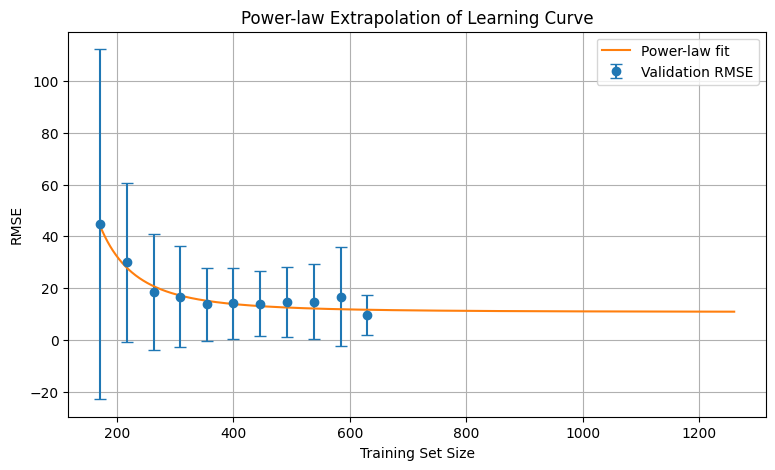

In [141]:
n = train_sizes_abs.astype(float)[1:]
rmse_mean = val_rmse[1:].mean(axis=1)
rmse_std = np.clip(val_rmse[1:].std(axis=1, ddof=1), 1e-6, None)

n_ref = np.median(n)

def f(n, a, b, c):
    return a + b * (n / n_ref) ** (-c)

a0 = rmse_mean[-1]
b0 = max(rmse_mean[0] - a0, 1e-6)
c0 = 0.5

a_lower = max(0.3 * rmse_mean.min(), 1e-6)

popt, pcov = curve_fit(
    f,
    n,
    rmse_mean,
    p0=[a0, b0, c0],
    sigma=rmse_std,
    absolute_sigma=True,
    bounds=([a_lower, 0, 0.05], [np.inf, np.inf, 20.0]),
    maxfev=20000
)

a, b, c = popt
pred = f(n, a, b, c)
res = rmse_mean - pred

weighted_r2 = 1 - np.sum((res / rmse_std) ** 2) / np.sum(
    ((rmse_mean - np.average(rmse_mean, weights=1 / rmse_std**2)) / rmse_std) ** 2
)

param_se = np.sqrt(np.diag(pcov))
dof = max(len(n) - len(popt), 1)
t_value = t.ppf(0.975, dof)

ci_lower = popt - t_value * param_se
ci_upper = popt + t_value * param_se

print("Fitted parameters:")
print(f"a = {a:.5f}  (95% CI: {ci_lower[0]:.5f}, {ci_upper[0]:.5f})")
print(f"b = {b:.5f}  (95% CI: {ci_lower[1]:.5f}, {ci_upper[1]:.5f})")
print(f"c = {c:.5f}  (95% CI: {ci_lower[2]:.5f}, {ci_upper[2]:.5f})")

print("\nFit diagnostics:")
print(f"Weighted R^2     = {weighted_r2:.4f}")
print(f"Mean residual    = {res.mean():.5f}")
print(f"Max abs residual = {np.abs(res).max():.5f}")
print(f"cond(pcov)       = {np.linalg.cond(pcov):.4e}")

grid_plot = np.linspace(n.min(), 2 * n.max(), 1000)

plt.figure(figsize=(9, 5))
plt.errorbar(n, rmse_mean, yerr=rmse_std, fmt="o", capsize=4, label="Validation RMSE")
plt.plot(grid_plot, f(grid_plot, a, b, c), label="Power-law fit")

plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.title("Power-law Extrapolation of Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

Current max N: 630
Predicted asymptotic RMSE: 10.7953
N for RMSE <= 12: 559
N where doubling gain < 0.2: 1004

Probabilistic estimates:
Valid Monte Carlo samples: 729
N for P(RMSE <= 12) >= 50%: 778
N for P(doubling gain < 0.2) >= 50%: 1197


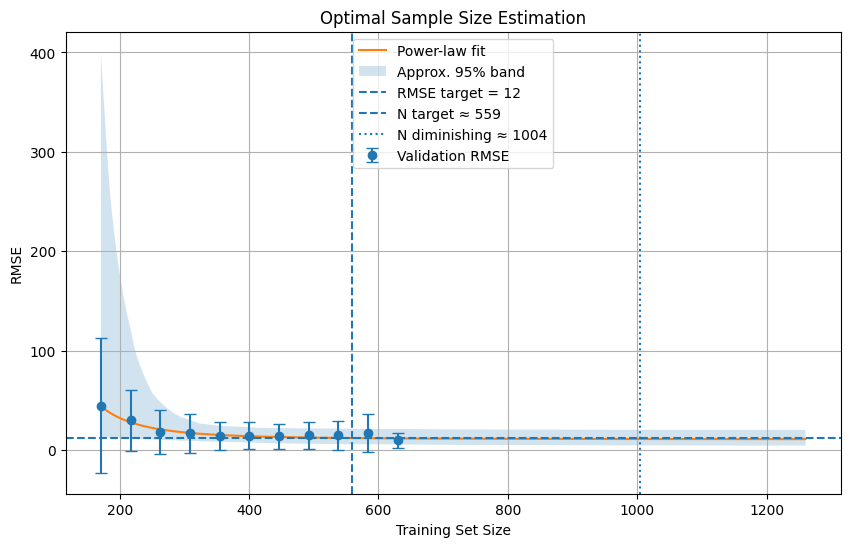

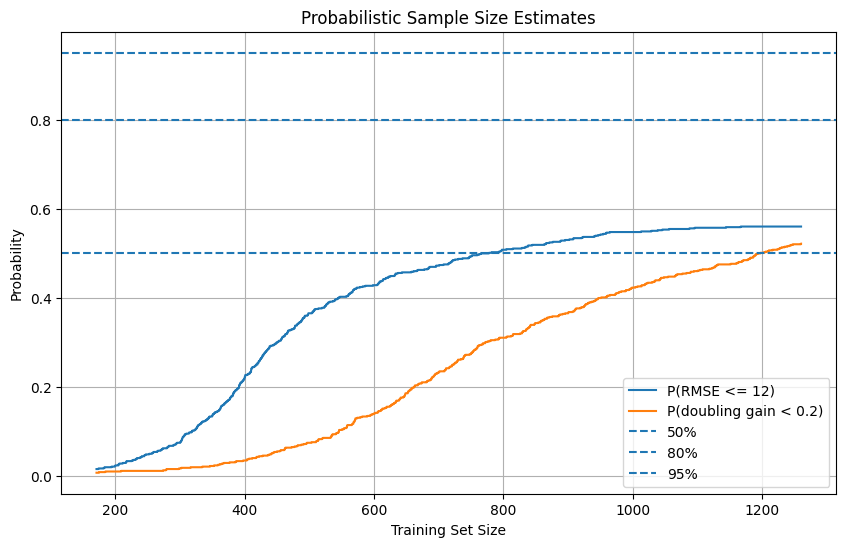

In [142]:
rmse_target = 12
delta = 0.2
n_mc = 3000

grid = np.linspace(n.min(), 2 * n.max(), 5000)
pred_rmse = f(grid, a, b, c)

target_idx = np.where(pred_rmse <= rmse_target)[0]
n_target = grid[target_idx[0]] if len(target_idx) else None

doubling_gain = pred_rmse - f(2 * grid, a, b, c)
diminishing_idx = np.where(doubling_gain < delta)[0]
n_diminishing = grid[diminishing_idx[0]] if len(diminishing_idx) else None

print(f"Current max N: {n.max():.0f}")
print(f"Predicted asymptotic RMSE: {a:.4f}")

if n_target is not None:
    print(f"N for RMSE <= {rmse_target}: {n_target:.0f}")
else:
    print(f"RMSE target {rmse_target} was not reached up to 30x current max N")

if n_diminishing is not None:
    print(f"N where doubling gain < {delta}: {n_diminishing:.0f}")
else:
    print(f"No N found up to 30x current max N where doubling gain < {delta}")

rng = np.random.default_rng(42)
samples = rng.multivariate_normal(popt, pcov, size=n_mc)

samples = samples[
    (samples[:, 0] >= a_lower) &
    (samples[:, 1] >= 0) &
    (samples[:, 2] >= 0.05)
]

print("\nProbabilistic estimates:")
print(f"Valid Monte Carlo samples: {len(samples)}")

if len(samples):
    pred_samples = np.array([f(grid, aa, bb, cc) for aa, bb, cc in samples])
    pred_samples_2x = np.array([f(2 * grid, aa, bb, cc) for aa, bb, cc in samples])

    prob_target = (pred_samples <= rmse_target).mean(axis=0)
    prob_diminishing = ((pred_samples - pred_samples_2x) < delta).mean(axis=0)

    def first_n(prob, threshold):
        idx = np.where(prob >= threshold)[0]
        return grid[idx[0]] if len(idx) else None

    n_target_50 = first_n(prob_target, 0.50)
    n_target_80 = first_n(prob_target, 0.80)
    n_target_95 = first_n(prob_target, 0.95)

    n_dim_50 = first_n(prob_diminishing, 0.50)
    n_dim_80 = first_n(prob_diminishing, 0.80)
    n_dim_95 = first_n(prob_diminishing, 0.95)

    if n_target_50 is not None:
        print(f"N for P(RMSE <= {rmse_target}) >= 50%: {n_target_50:.0f}")
    if n_target_80 is not None:
        print(f"N for P(RMSE <= {rmse_target}) >= 80%: {n_target_80:.0f}")
    if n_target_95 is not None:
        print(f"N for P(RMSE <= {rmse_target}) >= 95%: {n_target_95:.0f}")

    if n_dim_50 is not None:
        print(f"N for P(doubling gain < {delta}) >= 50%: {n_dim_50:.0f}")
    if n_dim_80 is not None:
        print(f"N for P(doubling gain < {delta}) >= 80%: {n_dim_80:.0f}")
    if n_dim_95 is not None:
        print(f"N for P(doubling gain < {delta}) >= 95%: {n_dim_95:.0f}")

    grid_plot = np.linspace(n.min(), 2 * n.max(), 1000)
    pred_plot = f(grid_plot, a, b, c)

    pred_samples_plot = np.array([f(grid_plot, aa, bb, cc) for aa, bb, cc in samples])
    lower_95 = np.percentile(pred_samples_plot, 2.5, axis=0)
    upper_95 = np.percentile(pred_samples_plot, 97.5, axis=0)

    plt.figure(figsize=(10, 6))
    plt.errorbar(n, rmse_mean, yerr=rmse_std, fmt="o", capsize=4, label="Validation RMSE")
    plt.plot(grid_plot, pred_plot, label="Power-law fit")
    plt.fill_between(grid_plot, lower_95, upper_95, alpha=0.2, label="Approx. 95% band")
    plt.axhline(rmse_target, linestyle="--", label=f"RMSE target = {rmse_target}")

    if n_target is not None:
        plt.axvline(n_target, linestyle="--", label=f"N target ≈ {n_target:.0f}")
    if n_diminishing is not None:
        plt.axvline(n_diminishing, linestyle=":", label=f"N diminishing ≈ {n_diminishing:.0f}")

    plt.xlabel("Training Set Size")
    plt.ylabel("RMSE")
    plt.title("Optimal Sample Size Estimation")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(grid, prob_target, label=f"P(RMSE <= {rmse_target})")
    plt.plot(grid, prob_diminishing, label=f"P(doubling gain < {delta})")
    plt.axhline(0.50, linestyle="--", label="50%")
    plt.axhline(0.80, linestyle="--", label="80%")
    plt.axhline(0.95, linestyle="--", label="95%")
    plt.xlabel("Training Set Size")
    plt.ylabel("Probability")
    plt.title("Probabilistic Sample Size Estimates")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No valid Monte Carlo samples after bounds filtering.")

Learning-type curve with NLS
Current max N: 630
Predicted asymptotic RMSE: 10.7953
N for RMSE <= 12: 559
N where doubling gain < 0.2: 1004

Probabilistic estimates for NLS:
Valid Monte Carlo samples: 517
N for P(doubling gain < 0.2) >= 50%: 1013

Learning-type curve with NLS + GP
N for RMSE <= 12: 756
N where doubling gain < 0.2: 1004
Learned GP kernel: 0.0188**2 * RBF(length_scale=0.955) + WhiteKernel(noise_level=0.000373)
Mean GP std: 0.05601104787925472
Max GP std : 0.05601113582971839
Min GP std : 0.05601098853718029

Probabilistic estimates for NLS + GP:
N for P(RMSE <= 12) >= 50%: 756
N for P(RMSE <= 12) >= 80%: 782
N for P(RMSE <= 12) >= 95%: 810
N for P(doubling gain < 0.2) >= 50%: 1004
N for P(doubling gain < 0.2) >= 80%: 1160


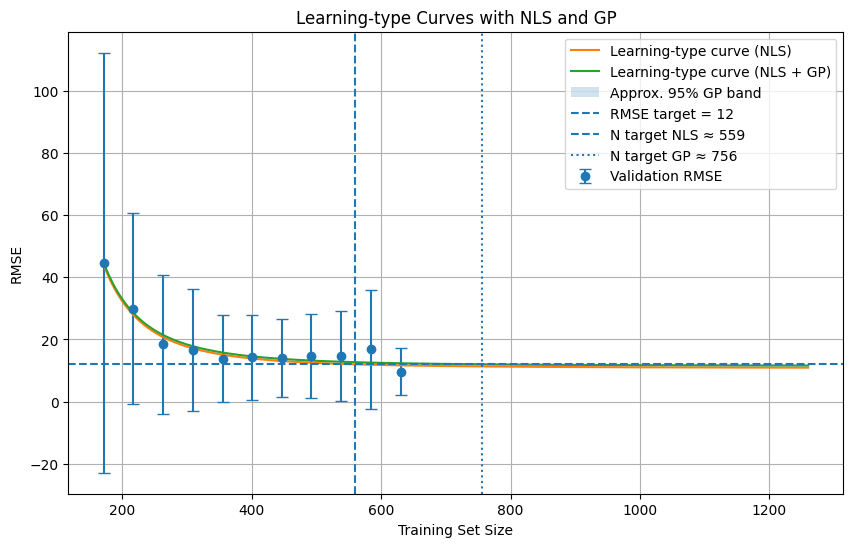

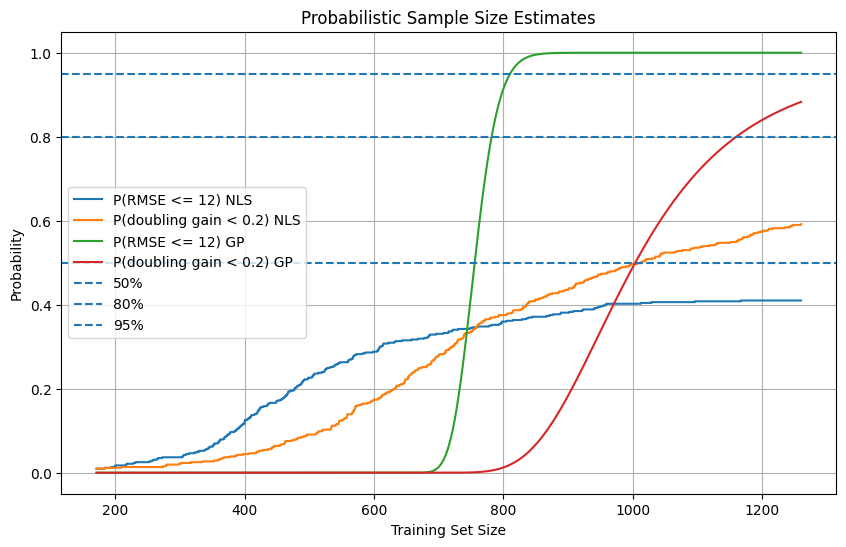

In [143]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

n = train_sizes_abs.astype(float)[1:]
rmse_mean = val_rmse[1:].mean(axis=1)
rmse_std = np.clip(val_rmse[1:].std(axis=1, ddof=1), 1e-6, None)

rmse_target = 12
delta = 0.2
n_mc = 3000

n_ref = np.median(n)

def f_nls(n, a, b, c):
    return a + b * (n / n_ref) ** (-c)

def first_n(prob, threshold, grid):
    idx = np.where(prob >= threshold)[0]
    return grid[idx[0]] if len(idx) else None

a0 = rmse_mean[-1]
b0 = max(rmse_mean[0] - a0, 1e-6)
c0 = 0.5
a_lower = max(0.8 * rmse_mean.min(), 1e-6)

popt, pcov = curve_fit(
    f_nls,
    n,
    rmse_mean,
    p0=[a0, b0, c0],
    sigma=rmse_std,
    absolute_sigma=True,
    bounds=([a_lower, 0.0, 0.05], [np.inf, np.inf, 20.0]),
    maxfev=20000
)

a, b, c = popt
pred_nls = f_nls(n, a, b, c)

x = np.log(n).reshape(-1, 1)
residuals = rmse_mean - pred_nls

kernel = (
    ConstantKernel(1.0, (1e-6, 1e3))
    * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
    + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-6, 1e2))
)

gpr = GaussianProcessRegressor(
    kernel=kernel,
    alpha=rmse_std**2,
    normalize_y=True,
    random_state=42
)

gpr.fit(x, residuals)

grid = np.linspace(n.min(), 2 * n.max(), 5000)
x_grid = np.log(grid).reshape(-1, 1)
x_grid_2x = np.log(2 * grid).reshape(-1, 1)

pred_nls_grid = f_nls(grid, a, b, c)
pred_nls_grid_2x = f_nls(2 * grid, a, b, c)

gp_res_mean, gp_res_std = gpr.predict(x_grid, return_std=True)
gp_res_mean_2x, gp_res_std_2x = gpr.predict(x_grid_2x, return_std=True)

gp_res_std = np.clip(gp_res_std, 1e-6, None)
gp_res_std_2x = np.clip(gp_res_std_2x, 1e-6, None)

pred_gp_grid = pred_nls_grid + gp_res_mean
pred_gp_grid_2x = pred_nls_grid_2x + gp_res_mean_2x

gp_lower_95 = pred_gp_grid - 1.96 * gp_res_std
gp_upper_95 = pred_gp_grid + 1.96 * gp_res_std

target_idx_nls = np.where(pred_nls_grid <= rmse_target)[0]
n_target_nls = grid[target_idx_nls[0]] if len(target_idx_nls) else None

doubling_gain_nls = pred_nls_grid - pred_nls_grid_2x
diminishing_idx_nls = np.where(doubling_gain_nls < delta)[0]
n_diminishing_nls = grid[diminishing_idx_nls[0]] if len(diminishing_idx_nls) else None

target_idx_gp = np.where(pred_gp_grid <= rmse_target)[0]
n_target_gp = grid[target_idx_gp[0]] if len(target_idx_gp) else None

doubling_gain_gp = pred_gp_grid - pred_gp_grid_2x
diminishing_idx_gp = np.where(doubling_gain_gp < delta)[0]
n_diminishing_gp = grid[diminishing_idx_gp[0]] if len(diminishing_idx_gp) else None

print("Learning-type curve with NLS")
print(f"Current max N: {n.max():.0f}")
print(f"Predicted asymptotic RMSE: {a:.4f}")

if n_target_nls is not None:
    print(f"N for RMSE <= {rmse_target}: {n_target_nls:.0f}")
else:
    print(f"RMSE target {rmse_target} was not reached up to 2x current max N")

if n_diminishing_nls is not None:
    print(f"N where doubling gain < {delta}: {n_diminishing_nls:.0f}")
else:
    print(f"No N found up to 2x current max N where doubling gain < {delta}")

rng = np.random.default_rng(42)
samples = rng.multivariate_normal(mean=popt, cov=pcov, size=n_mc)

samples = samples[
    (samples[:, 0] >= a_lower) &
    (samples[:, 1] >= 0.0) &
    (samples[:, 2] >= 0.05)
]

print("\nProbabilistic estimates for NLS:")
print(f"Valid Monte Carlo samples: {len(samples)}")

if len(samples):
    pred_samples = np.array([f_nls(grid, aa, bb, cc) for aa, bb, cc in samples])
    pred_samples_2x = np.array([f_nls(2 * grid, aa, bb, cc) for aa, bb, cc in samples])

    prob_target_nls = (pred_samples <= rmse_target).mean(axis=0)
    prob_diminishing_nls = ((pred_samples - pred_samples_2x) < delta).mean(axis=0)

    n_target_50_nls = first_n(prob_target_nls, 0.50, grid)
    n_target_80_nls = first_n(prob_target_nls, 0.80, grid)
    n_target_95_nls = first_n(prob_target_nls, 0.95, grid)

    n_dim_50_nls = first_n(prob_diminishing_nls, 0.50, grid)
    n_dim_80_nls = first_n(prob_diminishing_nls, 0.80, grid)
    n_dim_95_nls = first_n(prob_diminishing_nls, 0.95, grid)

    if n_target_50_nls is not None:
        print(f"N for P(RMSE <= {rmse_target}) >= 50%: {n_target_50_nls:.0f}")
    if n_target_80_nls is not None:
        print(f"N for P(RMSE <= {rmse_target}) >= 80%: {n_target_80_nls:.0f}")
    if n_target_95_nls is not None:
        print(f"N for P(RMSE <= {rmse_target}) >= 95%: {n_target_95_nls:.0f}")

    if n_dim_50_nls is not None:
        print(f"N for P(doubling gain < {delta}) >= 50%: {n_dim_50_nls:.0f}")
    if n_dim_80_nls is not None:
        print(f"N for P(doubling gain < {delta}) >= 80%: {n_dim_80_nls:.0f}")
    if n_dim_95_nls is not None:
        print(f"N for P(doubling gain < {delta}) >= 95%: {n_dim_95_nls:.0f}")
else:
    prob_target_nls = None
    prob_diminishing_nls = None

print("\nLearning-type curve with NLS + GP")

if n_target_gp is not None:
    print(f"N for RMSE <= {rmse_target}: {n_target_gp:.0f}")
else:
    print(f"RMSE target {rmse_target} was not reached up to 2x current max N")

if n_diminishing_gp is not None:
    print(f"N where doubling gain < {delta}: {n_diminishing_gp:.0f}")
else:
    print(f"No N found up to 2x current max N where doubling gain < {delta}")

print(f"Learned GP kernel: {gpr.kernel_}")
print(f"Mean GP std: {gp_res_std.mean()}")
print(f"Max GP std : {gp_res_std.max()}")
print(f"Min GP std : {gp_res_std.min()}")

prob_target_gp = norm.cdf((rmse_target - pred_gp_grid) / gp_res_std)

doubling_gain_gp_std = np.sqrt(gp_res_std**2 + gp_res_std_2x**2)
doubling_gain_gp_std = np.clip(doubling_gain_gp_std, 1e-6, None)
prob_diminishing_gp = norm.cdf((delta - doubling_gain_gp) / doubling_gain_gp_std)

n_target_50_gp = first_n(prob_target_gp, 0.50, grid)
n_target_80_gp = first_n(prob_target_gp, 0.80, grid)
n_target_95_gp = first_n(prob_target_gp, 0.95, grid)

n_dim_50_gp = first_n(prob_diminishing_gp, 0.50, grid)
n_dim_80_gp = first_n(prob_diminishing_gp, 0.80, grid)
n_dim_95_gp = first_n(prob_diminishing_gp, 0.95, grid)

print("\nProbabilistic estimates for NLS + GP:")
if n_target_50_gp is not None:
    print(f"N for P(RMSE <= {rmse_target}) >= 50%: {n_target_50_gp:.0f}")
if n_target_80_gp is not None:
    print(f"N for P(RMSE <= {rmse_target}) >= 80%: {n_target_80_gp:.0f}")
if n_target_95_gp is not None:
    print(f"N for P(RMSE <= {rmse_target}) >= 95%: {n_target_95_gp:.0f}")

if n_dim_50_gp is not None:
    print(f"N for P(doubling gain < {delta}) >= 50%: {n_dim_50_gp:.0f}")
if n_dim_80_gp is not None:
    print(f"N for P(doubling gain < {delta}) >= 80%: {n_dim_80_gp:.0f}")
if n_dim_95_gp is not None:
    print(f"N for P(doubling gain < {delta}) >= 95%: {n_dim_95_gp:.0f}")

plt.figure(figsize=(10, 6))
plt.errorbar(n, rmse_mean, yerr=rmse_std, fmt="o", capsize=4, label="Validation RMSE")
plt.plot(grid, pred_nls_grid, label="Learning-type curve (NLS)")
plt.plot(grid, pred_gp_grid, label="Learning-type curve (NLS + GP)")
plt.fill_between(grid, gp_lower_95, gp_upper_95, alpha=0.2, label="Approx. 95% GP band")
plt.axhline(rmse_target, linestyle="--", label=f"RMSE target = {rmse_target}")

if n_target_nls is not None:
    plt.axvline(n_target_nls, linestyle="--", label=f"N target NLS ≈ {n_target_nls:.0f}")
if n_target_gp is not None:
    plt.axvline(n_target_gp, linestyle=":", label=f"N target GP ≈ {n_target_gp:.0f}")

plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.title("Learning-type Curves with NLS and GP")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
if prob_target_nls is not None:
    plt.plot(grid, prob_target_nls, label=f"P(RMSE <= {rmse_target}) NLS")
    plt.plot(grid, prob_diminishing_nls, label=f"P(doubling gain < {delta}) NLS")

plt.plot(grid, prob_target_gp, label=f"P(RMSE <= {rmse_target}) GP")
plt.plot(grid, prob_diminishing_gp, label=f"P(doubling gain < {delta}) GP")

plt.axhline(0.50, linestyle="--", label="50%")
plt.axhline(0.80, linestyle="--", label="80%")
plt.axhline(0.95, linestyle="--", label="95%")

plt.xlabel("Training Set Size")
plt.ylabel("Probability")
plt.title("Probabilistic Sample Size Estimates")
plt.legend()
plt.grid(True)
plt.show()